# Notebook 04 — Reducción de dimensionalidad (PCA)

## Planteamiento de trabajo

El objetivo de esta etapa es aplicar **PCA (Análisis de Componentes Principales)** sobre las variables numéricas para resumir la información en menos dimensiones y entender cómo se estructuran los datos.

El PCA no se presenta solo como código: documentamos **qué variables usamos y por qué**, el **escalamiento** previo (indispensable), **cuánta varianza** explica cada componente y **qué representa** cada una (sus cargas).

**Pasos:** seleccionar variables → verificar faltantes → escalar → aplicar PCA → analizar varianza y componentes.

## 1. Carga del dataset

### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Se importan pandas y numpy, y las herramientas de scikit-learn para escalar y aplicar PCA.

### Carga del dataset limpio

In [2]:
df = pd.read_csv("../data/processed/streaming_users_processed.csv")
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,1
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1


Se carga el dataset ya procesado en el Notebook 02, desde `data/processed/`.

### Dimensiones

In [3]:
# Dimensiones del dataset procesado
df.shape

(8034, 8)

El dataset tiene 8034 filas y 8 columnas.

### Estructura y tipos

In [4]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8034 non-null   int64  
 1   age                       8034 non-null   float64
 2   subscription_plan         8034 non-null   str    
 3   monthly_watch_time_mins   8034 non-null   float64
 4   country                   8034 non-null   str    
 5   favorite_genre            8034 non-null   str    
 6   last_login_date           7548 non-null   str    
 7   customer_support_tickets  8034 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 502.3 KB


Confirmamos las variables y sus tipos; identificamos las numéricas, candidatas al PCA.

## 2. Selección de variables

### Variables numéricas disponibles

In [5]:
# Identificar variables numéricas
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns

variables_numericas

Index(['user_id', 'age', 'monthly_watch_time_mins',
       'customer_support_tickets'],
      dtype='str')

Las variables numéricas son `user_id`, `age`, `monthly_watch_time_mins` y `customer_support_tickets`.

### Variables elegidas para el PCA

In [6]:
# Selección de variables para PCA
variables_pca = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

df_pca = df[variables_pca]

df_pca.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,1
1,37.0,1173.4,2
2,28.0,401.0,0
3,43.0,62.4,0
4,51.0,477.8,1


Se eligen `age`, `monthly_watch_time_mins` y `customer_support_tickets`. Se excluye `user_id` porque es un identificador: no describe el comportamiento del usuario y agregaría ruido al análisis.

## 3. Verificación de valores faltantes

### Faltantes en las variables seleccionadas

In [7]:
# Verificar valores faltantes en las variables seleccionadas
df_pca.isnull().sum()

age                         0
monthly_watch_time_mins     0
customer_support_tickets    0
dtype: int64

Las tres variables están completas (0 faltantes), gracias a la limpieza del Notebook 02.

### Registros con algún faltante

In [8]:
# Cantidad de registros que contienen al menos un valor faltante
df_pca.isnull().any(axis=1).sum()

np.int64(0)

No hay ningún registro con datos faltantes en estas variables.

### Eliminación de faltantes (por precaución)

In [9]:
# Eliminar registros con valores faltantes
df_pca = df_pca.dropna()

# Verificar dimensiones del nuevo conjunto de datos
df_pca.shape

(8034, 3)

Como no hay faltantes, no se elimina ningún registro: se conservan los 8034.

### Confirmación

In [10]:
# Confirmar que ya no existan valores faltantes
df_pca.isnull().sum()

age                         0
monthly_watch_time_mins     0
customer_support_tickets    0
dtype: int64

Gracias a la limpieza realizada en el Notebook 02 (tratamiento de los valores inválidos de `age` y `customer_support_tickets`), las tres variables seleccionadas ya no presentan valores faltantes. Por lo tanto, no fue necesario eliminar registros y el conjunto quedó conformado por **8034 registros completos** y 3 variables numéricas. Con esta preparación finalizada, los datos cumplen las condiciones necesarias para aplicar el escalamiento mediante StandardScaler, etapa previa e indispensable para la ejecución del PCA.

## 4. Escalamiento de las variables

### Estandarización con StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
escalador = StandardScaler()

# Aplicar el escalamiento
datos_escalados = escalador.fit_transform(df_pca)

# Convertir el resultado en un DataFrame
df_escalado = pd.DataFrame(
    datos_escalados,
    columns=df_pca.columns
)

df_escalado.head().round(2)

,age,monthly_watch_time_mins,customer_support_tickets
0,0.47,0.01,0.22
1,0.29,0.76,1.34
2,-0.49,-0.82,-0.90
3,0.81,-1.51,-0.90
4,1.50,-0.66,0.22


El escalamiento permitió eliminar las diferencias de magnitud existentes entre las variables seleccionadas. Como resultado, todas las variables quedaron expresadas en una escala comparable, evitando que aquellas con valores numéricos más elevados influyan de manera desproporcionada en la construcción de las componentes principales.

Esta transformación constituye un paso previo indispensable para la aplicación del PCA, ya que garantiza que la reducción de dimensionalidad se base en las relaciones entre las variables y no en sus unidades de medida.

### Verificación del escalamiento

In [12]:
# Verificar medias y desviaciones estándar
df_escalado.agg(["mean", "std"]).round(2)

,age,monthly_watch_time_mins,customer_support_tickets
mean,-0.0,0.0,-0.0
std,1.0,1.0,1.0


Los resultados obtenidos validan que el proceso de estandarización fue exitoso. Al presentar medias cercanas a cero y desviaciones estándar iguales a uno, las variables quedaron correctamente normalizadas para la aplicación del PCA.


✅ Conclusión

El conjunto de datos cumple con las condiciones necesarias para aplicar el Análisis de Componentes Principales. Con las variables correctamente estandarizadas, es posible continuar con el cálculo de las componentes principales y analizar la proporción de varianza explicada por cada una de ellas.

## 5. Aplicación del PCA

### Cálculo de las componentes principales

In [13]:
from sklearn.decomposition import PCA

# Crear el modelo PCA
pca = PCA()

# Ajustar el modelo sobre los datos escalados
componentes_principales = pca.fit_transform(df_escalado)

# Mostrar las dimensiones del resultado
componentes_principales.shape

(8034, 3)

Se ajusta el PCA sobre los datos escalados. Se obtienen 3 componentes, una por cada variable de entrada.

## 6. Varianza explicada

### Varianza explicada por componente

In [14]:
# Crear un DataFrame con la varianza explicada
varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza explicada": pca.explained_variance_ratio_,
    "Varianza acumulada": pca.explained_variance_ratio_.cumsum()
})

varianza = varianza.round(2)

varianza

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.34,0.34
1,PC2,0.33,0.67
2,PC3,0.33,1.00


La distribución de la varianza explicada muestra que las tres componentes principales son relevantes para representar la información del conjunto de datos. Debido a que ninguna componente concentra una proporción ampliamente superior de la variabilidad, no se observa una reducción de dimensionalidad marcada. Esto indica que las tres variables originales aportan información complementaria al análisis.

## 7. Interpretación de las componentes (cargas)

### Cargas (loadings) de cada componente

In [15]:
# Cargas (loadings) de cada componente principal
cargas = pd.DataFrame(
    pca.components_,
    columns=df_escalado.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

cargas = cargas.round(2)

cargas

,age,monthly_watch_time_mins,customer_support_tickets
PC1,0.73,0.31,0.61
PC2,0.06,0.85,-0.52
PC3,0.68,-0.42,-0.60


El análisis de las cargas de las componentes principales permite identificar qué variables tienen mayor influencia en cada dimensión obtenida mediante PCA.

La primera componente (PC1) está determinada principalmente por la **edad** y la **cantidad de tickets de soporte**, por lo que combina un rasgo demográfico con la intensidad de contacto con el soporte. La segunda componente (PC2) está dominada por el **tiempo mensual de visualización**, resumiendo el comportamiento de consumo de la plataforma. La tercera componente (PC3) vuelve a combinar las tres variables, con un peso importante de la edad y del tiempo de visualización, aportando información que no fue capturada por las componentes anteriores.

En conjunto, cada variable original contribuye de manera diferenciada a una dimensión distinta, lo que es coherente con que la varianza se reparta de forma equilibrada entre las tres componentes: las variables aportan información complementaria y no redundante.

## 8. Visualización de la varianza

### Gráfico de varianza explicada

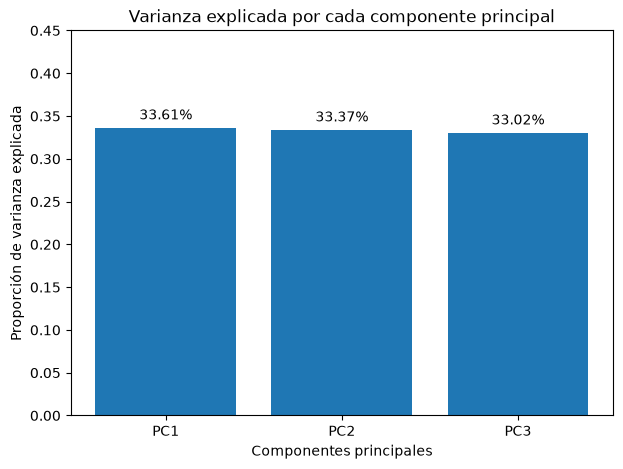

In [16]:
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(7,5))

# Gráfico de barras
plt.bar(
    ["PC1", "PC2", "PC3"],
    pca.explained_variance_ratio_,
)

plt.title("Varianza explicada por cada componente principal")
plt.xlabel("Componentes principales")
plt.ylabel("Proporción de varianza explicada")

# Mostrar porcentaje encima de cada barra
for i, valor in enumerate(pca.explained_variance_ratio_):
    plt.text(i, valor + 0.01, f"{valor:.2%}", ha="center")

plt.ylim(0, 0.45)

plt.show()

La representación gráfica confirma los resultados obtenidos mediante la tabla de varianza explicada. Las tres componentes principales contribuyen de forma similar a la representación de la información, por lo que no se identifica una reducción de dimensionalidad marcada. Este resultado refuerza la conclusión de que las variables originales aportan información complementaria y que el PCA permite analizar su estructura sin evidenciar una pérdida importante de redundancia.

## ¿Qué aporta el PCA? — Conclusión general

**Conclusión general del Notebook 04**

En este notebook se aplicó el Análisis de Componentes Principales (PCA) sobre las variables numéricas del dataset previamente preparado. Se documentó la selección de variables, el tratamiento de los valores faltantes y el proceso de estandarización necesario para la aplicación del algoritmo.

Posteriormente, se analizó la varianza explicada por cada componente principal, se interpretó el significado de las componentes mediante sus cargas y se realizaron visualizaciones que facilitaron la comprensión de la estructura de los datos. Los resultados evidenciaron que la variabilidad del conjunto se distribuye de forma equilibrada entre las tres componentes principales, por lo que no se observó una reducción marcada de la dimensionalidad.

En conjunto, el PCA aportó una visión complementaria del análisis exploratorio realizado previamente, permitiendo comprender mejor la organización de las variables y confirmar que cada una contribuye con información relevante para describir el comportamiento de los usuarios.